# Pairs trading: Engle-Granger cointegration (Static pairs selection & beta) with half-life filter - Second iteration

Universe: crypto pairs, daily bars  
Train: 2022-01-01 → 2024-01-01  
Test: 2024-01-02 → 2026-05-22

**Following on from the correlation-filter strategy**, I now test an Engle–Granger cointegration filter combined with a half-life mean-reversion filter, to understand whether a stronger pair-selection rule improves the strategy — still on a fully *static* basis (pairs and hedge ratios fixed on the training set), to gain a broad understanding of which filter approach to use before the next notebook addresses the static-beta limitation itself with a rolling hedge ratio.

**Why cointegration.** The correlation baseline picked pairs that *move together*, but co-movement of returns says nothing about whether the gap between two prices is stable. A highly correlated pair can drift apart for months, so the spread never reverts and the trade just bleeds. Cointegration addresses this directly: it tests whether a combination of the two price *levels* is stationary — whether there is a genuine long-run relationship. 

**Controlled comparison.** Every parameter downstream of selection is held identical to the correlation notebook — same train/test split, 90% coverage screen, 180-day z-score window, entry at |z|>2.5, exit at |z|<0.5, gross exposure normalised to 1, and the same flat-20bps and liquidity-aware cost models. Only the *selection rule* changes. So any difference in performance is attributable to how pairs are chosen, not to tuning.

Pipeline: select cointegrated pairs on training data (two-way EG, p<0.01, 
max 1 pair per coin) → filter by half-life of mean reversion (4-20 days) → 
build spread with static OLS hedge ratio → rolling 180-day z-score → 
enter at |z|>2.5, exit at |z|<0.5 → normalize gross exposure to 1.

**Key findings — cointegration + half-life (static)**

Cointegration looks a better filter than correlation. After selecting pairs on the first 2 years of data, the OOS net metrics all improve: the Sharpe rises to 2.46 (from 0.80), the full-sample information ratio to 4.6 (from 1.0), and the worst drawdown duration falls to 107 days (from 538). Screening for spreads that are genuinely stationary, rather than just co-moving, gives positions that actually revert, so drawdowns are both shallower and recover faster.

That said, the IS numbers look unrealistic. A net Sharpe above 7 over the training window is far too high, and the size of the gap to the OOS period (Sharpe 2.46, return ~39%) shows how much the result is flattered by selecting and fitting the pairs on that same data. So while the purely static approach still produces a strong, BTC-uncorrelated OOS result after selecting on the training window, it is clearly overfitted.

This all points to the need for a rolling beta calculation. Re-estimating the hedge ratio over time would add dynamism, reduce the reliance on a single training-period fit, and is the natural next step to narrow that IS/OOS gap.

*Performance by sample — net of 20 bps*

| Metric | In-sample | Out-of-sample | Full sample | BTC HODL |
|:--|--:|--:|--:|--:|
| Sharpe | 7.55 | 2.46 | 5.14 | 0.49 |
| Annualised return | 191.8% | 39.3% | 109.1% | 25.0% |
| Annualised vol | 25.4% | 16.0% | 21.2% | 51.4% |
| Hit rate | 68.7% | 57.1% | 62.1% | 49.6% |
| Max drawdown | −5.4% | −8.7% | −8.7% | −66.7% |
| Max DD duration (days) | 12 | 107 | 107 | 682 |

*Risk-adjusted vs BTC & portfolio (full sample, net)*

| Metric | Value |
|:--|--:|
| Alpha t-stat | 9.74 |
| Information ratio | 4.62 |
| Beta to BTC | −0.002 |
| Daily turnover | 9.5% |
| Avg holding period | ~21 days |

> Next step (separate notebook): relax the static hedge ratio for the cointegration strategy — re-estimate β on a rolling basis so the spread can track a relationship that drifts over time.



In [2]:
# ____ Imports and data loading ____
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import statsmodels.api as sm
# Cointegration-specific: pair enumeration, parallel execution, Engle-Granger test
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from joblib import Parallel, delayed
from statsmodels.tsa.stattools import coint

def read_crypto_data(interval):
    """
    Load cached price and volume pickles for a given timeframe
    interval:
        One of ["1d", "8h", "4h", "1h"] matching saved files.
    """
    path_px = Path(f"data_output/crypto_px_{interval}.pkl")
    path_vol = Path(f"data_output/crypto_vol_{interval}.pkl")
    if not path_px.exists() or not path_vol.exists():
        raise FileNotFoundError(f"Missing pickle files for interval {interval}")
    crypto_px = pd.read_pickle(path_px)
    crypto_vol = pd.read_pickle(path_vol)
    return crypto_px, crypto_vol

In [3]:
# ___ Functions for key stats/turnover/sharpe ____
# Annualisation helper
PERIODS_PER_YEAR = {"1d": 365, "8h": 365*3, "4h": 365*6, "1h": 365*24}

def compute_sharpe(rets,ppy=365):
    mean = rets.mean()*ppy # Crypto trades every day
    vol = rets.std()*np.sqrt(ppy)
    sharpe = mean / vol
    return sharpe

def drawdown(rets):
    cum = (1+rets).cumprod()
    return cum/cum.cummax()  - 1

def max_dd(rets):
    return drawdown(rets).min()

def max_dd_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return int(underwater.groupby(groups).cumsum().max())

def compute_keystats(rets, ppy=365):
    rets = rets.dropna()
    if len(rets) == 0:
        return pd.Series({'avg': np.nan, 'vol': np.nan, 'sharpe': np.nan, 
                          'hit_rate': np.nan, 'max_dd': np.nan, 'max_dd_duration': np.nan,
        })
    avg = rets.mean() * ppy
    vol = rets.std() * np.sqrt(ppy)
    sharpe = avg / vol if vol > 0 else np.nan
    hit_rate = (rets > 0).sum() / (rets != 0).sum() if (rets != 0).any() else np.nan
    return pd.Series({'avg': avg, 'vol': vol, 'sharpe': sharpe, 
                      'hit_rate': hit_rate, 'max_dd':max_dd(rets),'max_dd_duration':max_dd_duration(rets)})

def compute_turnover(port):
    to = (port.fillna(0)-port.shift().fillna(0)).abs().sum(1)   
    return to

## Selecting pairs by cointegration (two-way Engle–Granger)

We screen every coin pair on the training window and keep only those that are *cointegrated* — whose log-price spread is statistically stationary rather than wandering.

**Why Engle–Granger rather than a plain ADF test.** A usual approach builds a spread and runs an Augmented Dickey–Fuller test on it. The catch is that the spread isn't observed — its hedge ratio is estimated by regression first — and a standard ADF test assumes the series was *given*, not fitted. This can often over-reject and flags spurious cointegration. Engle–Granger is my preferred procedure here: it runs the regression and tests the residual using critical values adjusted for the fact that the relationship was estimated.

**Why two-way.** Engle–Granger isn't symmetric — regressing coin A on coin B gives a different test statistic and hedge ratio than B on A, and a pair can sometimes look cointegrated in one direction but not the other purely because of which coin is treated as dependent. So we run the test both ways and keep the *worse* p-value, accepting a pair only if it passes regardless of direction. This is a deliberately conservative screen.

We require a p-value below 0.01 for a conservative screen and, as in the baseline, allow each coin into at most one pair.

In [4]:
# ____ Engle-Granger two-way cointegration test for one pair (training data) ____
def adf_for_pair(coin_i, coin_j, train_px):
    # Align both series on common non-NaN, non-zero dates
    paired = train_px[[coin_i, coin_j]].replace(0, np.nan).dropna()
    
    if len(paired) < 60:   # not enough data for a meaningful test
        return (coin_i, coin_j), (1.0, 0.0, 0.0, 1.0)
    
    Y = np.log(paired[coin_i]).values
    X = np.log(paired[coin_j]).values

    try:
        # Test both directions and keep the WORSE p-value — a pair only qualifies if ...
        # ...it's cointegrated whichever coin is the dependent one (conservative)
        # Y on X
        t_stat_1, p_value_1, _ = coint(Y, X)
        # X on Y
        t_stat_2, p_value_2, _ = coint(X, Y)
        p_value = max(p_value_1, p_value_2)
        t_stat  = max(t_stat_1, t_stat_2)
        # Static OLS hedge ratio (log Y on log X) — frozen and reused in the backtest
        model = sm.OLS(Y, sm.add_constant(X)).fit()
        alpha = model.params[0]
        beta  = model.params[1]
    except (ValueError, np.linalg.LinAlgError):
        return (coin_i, coin_j), (1.0, 0.0, 0.0, 1.0)   # fail-safe: p=1 → never selected
    return (coin_i, coin_j), (p_value, t_stat, alpha, beta)

## Half-life of mean reversion filter

Cointegration tells us a spread reverts *eventually*, but not *how fast*. A pair can be statistically cointegrated yet take many months to revert. The half-life filter adds a further economic screen to reduce stretching out holdings.

**How it works.** We model each qualifying spread $s_t$ as a mean-reverting process: today's change in the spread depends on how far it sat from its mean yesterday,

$$\Delta s_t = -\lambda\,(s_{t-1} - \mu) + \varepsilon_t,$$

where $\Delta s_t = s_t - s_{t-1}$ and $\mu$ is the spread's long-run level. The intuition: when $s_{t-1}$ is above its mean the expected change is negative (it gets pulled back down), and vice versa, with $\lambda$ setting how strongly.

- **$\lambda$ — the speed of reversion.** We estimate it as minus the OLS slope of $\Delta s_t$ on the lagged level $s_{t-1}$,
$$\hat\lambda = -\,\frac{\operatorname{Cov}(s_{t-1},\,\Delta s_t)}{\operatorname{Var}(s_{t-1})}.$$
The mean $\mu$ is absorbed by the regression; only the slope matters here. If $\hat\lambda \le 0$ the spread isn't reverting at all (it's drifting or diffusing), so the pair is rejected.
- **Half-life.** A deviation decays toward the mean at rate $\lambda$ per day, so the time for a typical deviation to fall *halfway* back is
$$\text{half-life} = \frac{\ln 2}{\lambda}.$$
A fast-reverting spread has a short half-life; a sluggish one a long (or effectively infinite) half-life.

**Why these bounds (4–20 days).** We keep only pairs whose half-life sits in a tradeable band on daily bars:
- The lower bound (~4 days) drops spreads that revert almost instantly — on daily data those moves are mostly noise and would be churned away by transaction costs.
- The upper bound (~20 days) drops sluggish spreads that tie up capital for almost a month and leave positions exposed to the relationship drifting.

As everywhere else, these thresholds are fixed on training data and not re-tuned on the test set.

In [5]:
# ____ Half-life of mean reversion filter ___
def compute_half_life(spread):
    """
    Compute the half-life of mean reversion for a spread series.
    Uses the OLS regression: Δz_t = -λ * z_{t-1} + ε
    Half-life = ln(2) / λ
    Returns half-life in bars (days for 1d data).
    Returns np.inf if the series isn't mean-reverting (λ <= 0).
    """
    spread = spread.dropna()
    if len(spread) < 30:
        return np.inf
    
    z_lag = spread.shift(1).dropna()   # yesterday's spread level
    dz = spread.diff().dropna()        # today's change in the spread
    # Align
    z_lag, dz = z_lag.align(dz, join='inner')
    
    if len(z_lag) < 10 or z_lag.var() == 0:
        return np.inf
    # OLS slope of dz on z_lag via cov/var; λ = -slope is the pull-back speed
    beta = np.cov(z_lag, dz, ddof=1)[0, 1] / np.var(z_lag, ddof=1)
    lambda_hat = -beta
    if lambda_hat <= 0:
        return np.inf  # not mean-reverting
    
    return np.log(2) / lambda_hat


def filter_pairs_by_half_life(pairs_df, train_px, max_half_life=30, min_half_life=2):
    """
    Filter pairs_df to keep only those with mean-reversion half-life within bounds.
    Uses the same alpha/beta from pairs_df to construct the spread.
    """
    keep_rows = []
    half_lives = []
    
    for _, row in pairs_df.iterrows():
        coin_i, coin_j = row['coin1'], row['coin2']
        alpha, beta = row['alpha'], row['beta']
        
        # Rebuild the training spread with the frozen hedge ratio
        log_i = np.log(train_px[coin_i].replace(0, np.nan).ffill())
        log_j = np.log(train_px[coin_j].replace(0, np.nan).ffill())
        spread = log_i - beta * log_j - alpha
        
        hl = compute_half_life(spread)
        half_lives.append(hl)
        
        # Keep only pairs that revert on a tradeable horizon
        if min_half_life <= hl <= max_half_life:
            keep_rows.append(row)
    
    filtered = pd.DataFrame(keep_rows).reset_index(drop=True)
    
    print(f"  Half-life filter: {len(pairs_df)} → {len(filtered)} pairs "
          f"(kept {min_half_life} ≤ HL ≤ {max_half_life} days)")
    print(f"  Half-life distribution (all): "
          f"min={min(half_lives):.1f}, median={np.median(half_lives):.1f}, "
          f"max={max([h for h in half_lives if h != np.inf], default=np.inf):.1f}, "
          f"inf={sum(1 for h in half_lives if h == np.inf)}")
    
    return filtered, half_lives

In [6]:
# ____ Full ADF using Parelllel to reduce runtime ___
def adf_full(train_px):
    coins = train_px.columns.tolist()
    pairs = list(combinations(coins,2))
    # Parallel computation of ADF test for all pairs
    adf_results = Parallel(n_jobs=-1)(
        delayed(adf_for_pair)(coin_i, coin_j, train_px) for coin_i, coin_j in pairs)
    pairs, results = zip(*adf_results)
    adf_df = pd.DataFrame(results, columns=['p_value', 'test_statistic','alpha','beta'], index=pairs)
    adf_df = adf_df.sort_values(by='test_statistic')
    return adf_df

In [7]:
# ____ Function to choose pairs of coins based on cointegration ___
def sel_coint_pairs(train_px, sig_level = 0.01, max_pairs_per_coin = 1):
    adf_df = adf_full(train_px)
    qualified_df = adf_df[adf_df['p_value']<sig_level].copy()   # significantly cointegrated only
    if qualified_df.empty:
        return pd.DataFrame(columns=['coin1', 'coin2', 'p_value', 'test_statistic'
                                    ,'alpha','beta'])
    # Sort by most negative t-stat
    qualified_df = qualified_df.sort_values(by='test_statistic')
    # Flatten the pair tuples in the index into two columns
    qualified_df['coin1'] = [pair[0] for pair in qualified_df.index]
    qualified_df['coin2'] = [pair[1] for pair in qualified_df.index]
    qualified_df = qualified_df.reset_index(drop=True)
    
    # Keep each pair only if neither coin has hit its usage cap yet
    # (greedy from strongest down → stops one coin dominating the book)
    used = Counter()
    keep = []
    for _, row in qualified_df.iterrows():
        if used[row.coin1] < max_pairs_per_coin and used[row.coin2] < max_pairs_per_coin:
            keep.append(row)
            used[row.coin1] += 1
            used[row.coin2] += 1          
    pairs_df = pd.DataFrame(keep).reset_index(drop=True)
    pairs_df = pairs_df[['coin1', 'coin2', 'p_value', 'test_statistic','alpha','beta']]
    return pairs_df

In [8]:
# ___ Signal construction (spread → z-score) ___
def build_signals(px, pairs_df, window = 180):
    key_params = {}
    for _,row in pairs_df.iterrows():
        asset_i = row['coin1']
        asset_j = row['coin2']
        alpha = row['alpha']
        beta = row['beta']
        pair = (asset_i, asset_j)

        log_i = np.log(px[asset_i].replace(0, np.nan).ffill())
        log_j = np.log(px[asset_j].replace(0, np.nan).ffill())
        # Spread built with the STATIC hedge ratio, applied across the full series
        resid = log_i - (beta * log_j) - alpha
        # Standardise on a rolling window (rolling z-score, NOT a rolling beta)
        resid_mean = resid.rolling(window=window, min_periods=window//2).mean()
        resid_std = resid.rolling(window=window, min_periods=window//2).std()
        z_score = (resid - resid_mean) / resid_std
        key_params[(pair, 'beta')] = pd.Series(beta, index=px.index)
        key_params[(pair, 'alpha')] = pd.Series(alpha, index=px.index)
        key_params[(pair, 'resid')] = resid
        key_params[(pair, 'z_score')] = z_score
    return pd.DataFrame(key_params)

In [9]:
# ____ Position sizing (z-score → weights) ____
def build_weights(key_params, pairs_df, z_entry = 2.5, z_exit = 0.5):
    """ Convert the pair-level z-scores into per-coin portfolio weights. 
    Then normalise so absolute sum of weights equal to 1"""
    pairs = list(zip(pairs_df['coin1'], pairs_df['coin2']))
    coins = sorted({c for pair in pairs for c in pair})
    raw = pd.DataFrame(index=key_params.index, columns=coins, dtype=float)
    for pair in pairs:
        asset_i, asset_j = pair
        z = key_params[(pair, 'z_score')]
        beta = key_params[(pair, 'beta')]

        # Entries
        raw.loc[z > z_entry,  asset_i] = -1
        raw.loc[z > z_entry,  asset_j] = beta
        raw.loc[z < -z_entry, asset_i] = 1
        raw.loc[z < -z_entry, asset_j] = -beta
        # Exits override entries when |z| is small
        flat = z.abs() < z_exit
        raw.loc[flat, asset_i] = 0
        raw.loc[flat, asset_j] = 0

    # Hold previous position between entry and exit thresholds
    raw = raw.ffill()
    # Normalise per bar so |weights|.sum = 1 (or 0 if all flat)
    pos = raw.divide(raw.abs().sum(axis=1),axis=0).fillna(0)

    return pos

In [10]:
# ___ Backtest formula ____
def backtest(px, pos):
    simple_ret = px.pct_change(fill_method = None)
    cols = [c for c in pos.columns if c in simple_ret.columns]
    port_ret = (pos[cols].shift(1) * simple_ret[cols]).sum(axis=1) # Avoid lookahead bias
    return port_ret

In [11]:
# ____ Main run and stats for different sample periods ____
def run_strategy(px, pairs_df,  window=180, z_entry=2.5, z_exit=0.5):
    """
    Run the full pipeline on a price series and return strategy returns.
    """
    signals = build_signals(px, pairs_df, window=window)
    weights = build_weights(signals, pairs_df,
                            z_entry=z_entry, z_exit=z_exit)
    port_ret = backtest(px, weights)
    return port_ret, weights, signals

def split_stats(port_ret, split_date, ppy=365):
    """
    Compute key stats for in-sample, out-of-sample, and full-sample periods.
    split_date: first date of the out-of-sample period.
    """
    in_sample = port_ret.loc[:split_date].iloc[:-1]   # exclude split_date itself
    out_sample = port_ret.loc[split_date:]
    full_sample = port_ret

    stats = pd.DataFrame({
        'in_sample': compute_keystats(in_sample, ppy=ppy),
        'out_sample': compute_keystats(out_sample, ppy=ppy),
        'full_sample': compute_keystats(full_sample, ppy=ppy),
    })
    return stats

## Performance Evaluation

We run one configuration ($|z|>2.5$ entry, $|z|<0.5$ exit, 180-day z-window, half-life mean reversion (4-20 days)) and report — for in-sample, out-of-sample and full-sample periods, against a BTC buy-and-hold benchmark:

- **Annualised return** and **annualised volatility** (365 periods/year — crypto trades every day).
- **Sharpe ratio** — risk-adjusted return.
- **Hit rate** — share of non-flat days that are positive.
- **Max drawdown** and **drawdown duration** — depth and length of the worst peak-to-trough.
- **Turnover** and **implied holding period** — average daily fraction of the book traded, and $\approx 2/\text{turnover}$ days per round trip.
- **Alpha, beta and information ratio vs BTC** (HAC standard errors) — to confirm returns aren't just disguised BTC exposure.

**Costs.** Crypto commissions run ~7 bps. Slippage is trader- and size-dependent; we assume a further 13 bps, for ~20 bps all-in on market orders. We report two cost models: a flat 20 bps on all turnover, and, at the end of the notebook, a **liquidity-aware** model charging 7 bps on coins whose 30-day rolling dollar volume exceeds \$10m and 20 bps otherwise.

After EG cointegration: 64 pairs
  Half-life filter: 64 → 62 pairs (kept 4 ≤ HL ≤ 20 days)
  Half-life distribution (all): min=3.6, median=9.5, max=20.5, inf=0
After half-life filter: 62 pairs


/var/folders/_k/7nk8p4v11qg9b_q6yp7rdd_80000gn/T/ipykernel_18071/4102580241.py:29: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  btc_ret = crypto_px['BTC/USDT'].pct_change().dropna()



Stats by sample (gross of fees):
                 in_sample  out_sample  full_sample    btc_hodl
avg               2.016093    0.438014     1.159901    0.250327
vol               0.256257    0.160259     0.213632    0.514379
sharpe            7.867454    2.733170     5.429438    0.486660
hit_rate          0.697348    0.579254     0.629753    0.496222
max_dd           -0.053301   -0.082391    -0.082391   -0.667306
max_dd_duration  12.000000  103.000000   103.000000  682.000000


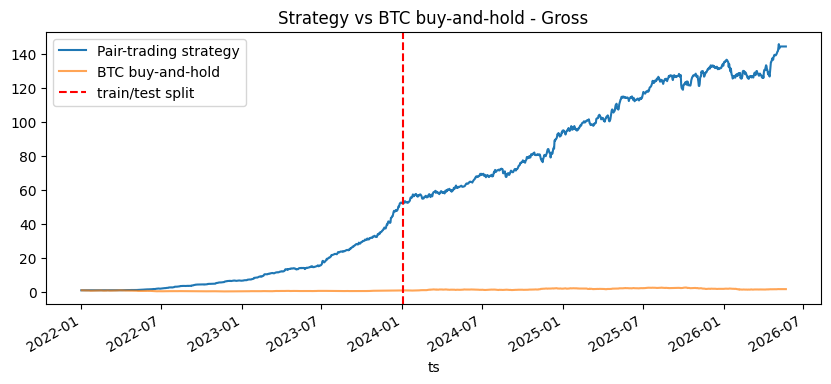

In [12]:
split_date = "2024-01-02"
split_ts = pd.to_datetime(split_date)
crypto_px, crypto_vol = read_crypto_data("1d")
train_px = crypto_px.loc[:"2024-01-01"].copy()
coverage = train_px.notna().mean()
eligible = coverage[
    coverage >= 0.90
].index
crypto_px = crypto_px[eligible]
crypto_vol = crypto_vol[eligible]
train_px = train_px[eligible]

# 1. Cointegration pair selection on training data
pairs_df = sel_coint_pairs(train_px, sig_level=0.01, max_pairs_per_coin=1)
print(f"After EG cointegration: {len(pairs_df)} pairs")

# 2. Half-life filter
pairs_df, half_lives = filter_pairs_by_half_life(
    pairs_df, train_px, max_half_life=20, min_half_life=4)
print(f"After half-life filter: {len(pairs_df)} pairs")

# 3. Run strategy on FULL price series 
port_ret, weights, signals = run_strategy(
    crypto_px, pairs_df, window=180, z_entry=2.5, z_exit=0.5
)

# 4. Get stats by period
stats = split_stats(port_ret, split_date=split_date, ppy=365)
btc_ret = crypto_px['BTC/USDT'].pct_change(fill_method=None)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined = pd.concat([stats, btc_full], axis=1)
print("\nStats by sample (gross of fees):")
print(combined)

# 5. Plot equity curve with split marker
equity = (1 + port_ret).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity.plot(figsize=(10, 4), label='Pair-trading strategy')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title("Strategy vs BTC buy-and-hold - Gross")
ax.legend()
plt.show()

Turnover is 0.09471573657679566
Corresponding holding period is 21.115815304655282

Stats by sample (net of 20bps):
                 in_sample  out_sample  full_sample    btc_hodl
avg               1.917935    0.393335     1.090759    0.250327
vol               0.254184    0.159704     0.212004    0.514379
sharpe            7.545446    2.462895     5.144981    0.486660
hit_rate          0.686916    0.571096     0.620667    0.496222
max_dd           -0.054425   -0.087044    -0.087044   -0.667306
max_dd_duration  12.000000  107.000000   107.000000  682.000000


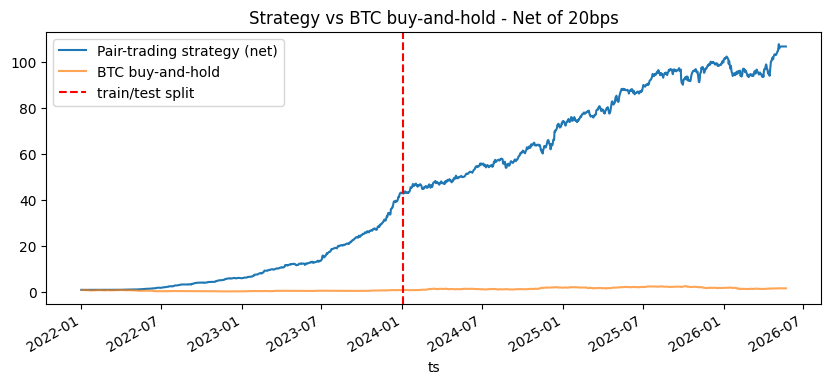

In [13]:
# ____ Net returns (based on 20bps) + stats ____
tcost_bps = 20  # 20 bps for market orders (commissions + slippage)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(to * tcost_bps * 1e-4, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")
# ---------- Stats ----------
stats_net = split_stats(port_ret_net, split_date=split_date, ppy=365)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nStats by sample (net of {tcost_bps}bps):")
print(combined_net)

equity_net = (1 + port_ret_net).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of {tcost_bps}bps")
ax.legend()
plt.show()

In [14]:
# ____ BM-adjusted performance vs BTC ___
def alpha_beta_block(strat_ret, btc_ret, label, ppy=365, roll_window=365, hac_lags=5):
    """Compute beta, alpha, alpha t-stat, IR"""
    df = pd.concat([strat_ret.rename('strat'), btc_ret.rename('btc')], axis=1).dropna()

    # Rolling PIT beta + residuals
    corr = df['strat'].rolling(roll_window).corr(df['btc'])
    vol_s = df['strat'].rolling(roll_window).std()
    vol_b = df['btc'].rolling(roll_window).std()
    beta_roll = corr * vol_s / vol_b
    resid = df['strat'] - beta_roll * df['btc']
    ir = resid.mean() / resid.std() * np.sqrt(ppy) if resid.std() > 0 else np.nan

    # Full-sample OLS for alpha + t-stat
    X = sm.add_constant(df['btc'])
    model = sm.OLS(df['strat'], X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    alpha_ann   = model.params['const'] * ppy
    beta_full   = model.params['btc']
    alpha_tstat = model.tvalues['const']
    stats = pd.Series({'beta_OLM': beta_full, 'alpha_ann':   alpha_ann, 'alpha_tstat': alpha_tstat,
        'ir':ir,}, name=label)
    return stats, resid

# Apply to gross and net
gross_ab, gross_resid = alpha_beta_block(port_ret, btc_ret, 'gross')
net_ab, net_resid   = alpha_beta_block(port_ret_net, btc_ret, 'net')

ab_table = pd.concat([gross_ab, net_ab], axis=1)
print("\nAlpha/Beta/IR vs BTC:")
print(ab_table)

corr_df = pd.concat([
    net_resid.rename('resid_net'),
    btc_ret.rename('btc'),
], axis=1).dropna()
print("Correlation of resids with BTC matrix:")
print(corr_df.corr().round(3))


Alpha/Beta/IR vs BTC:
                 gross       net
beta_OLM     -0.003269 -0.002015
alpha_ann     1.161446  1.091946
alpha_tstat  10.183161  9.738085
ir            4.922089  4.616268
Correlation of resids with BTC matrix:
           resid_net    btc
resid_net      1.000  0.004
btc            0.004  1.000


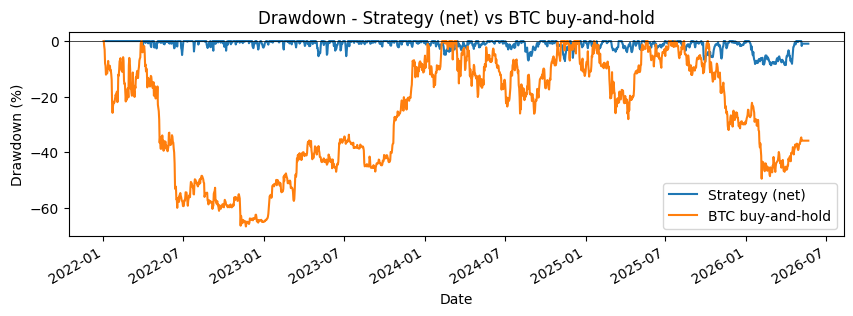

Max drawdown - Strategy (net):   -8.70%
Max drawdown - BTC buy-and-hold: -66.73%


In [15]:
# ___ Drawdown: Strategy (net) vs BTC buy-and-hold ___
comb_ret = pd.concat([
    port_ret_net.rename('strat_ret'),
    btc_ret.rename('buy_and_hold_btc'),
], axis=1).dropna()

dd = drawdown(comb_ret) * 100

plt.figure(figsize=(10, 3))
dd.plot(ax=plt.gca())
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Drawdown - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()
print(f"Max drawdown - Strategy (net):   {dd['strat_ret'].min():.2f}%")
print(f"Max drawdown - BTC buy-and-hold: {dd['buy_and_hold_btc'].min():.2f}%")

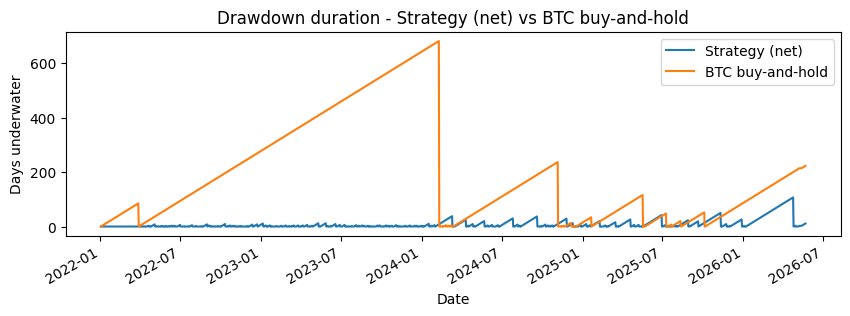

Max drawdown duration - Strategy (net):   107 days
Max drawdown duration - BTC buy-and-hold: 682 days


In [16]:
# ___ Drawdown duration: Strategy (net) vs BTC buy-and-hold ___
def drawdown_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return underwater.groupby(groups).cumsum()

ddd = comb_ret.apply(drawdown_duration)

plt.figure(figsize=(10, 3))
ddd.plot(ax=plt.gca())
plt.title('Drawdown duration - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Days underwater')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()

print(f"Max drawdown duration - Strategy (net):   {int(ddd['strat_ret'].max())} days")
print(f"Max drawdown duration - BTC buy-and-hold: {int(ddd['buy_and_hold_btc'].max())} days")

In [ ]:
# Gross exposure should be ~1.0 every day (or 0 when fully flat)
gross = weights.abs().sum(axis=1)
print("\nGross exposure stats:")
print(gross.describe())
print(f"\nDays with gross == 0 (fully flat): {(gross == 0).sum()}")
print(f"Days with gross ~= 1: {((gross > 0.99) & (gross < 1.01)).sum()}")
print(f"\nGross exposure around split:")
print(gross.loc[split_ts - pd.Timedelta(days=2):split_ts + pd.Timedelta(days=2)])

In [17]:
# ____ Net returns — liquidity-aware cost model ___
def compute_liquidity_aware_costs(weights, crypto_px, crypto_vol,
                                   high_liquidity_threshold_usd=10_000_000,
                                   slow_bps=7, fast_bps=20,
                                   rolling_days=30):
    w = weights.fillna(0)
    pos_change = (w - w.shift().fillna(0)).abs()
    dollar_vol = crypto_px * crypto_vol
    rolling_dvol = dollar_vol.rolling(rolling_days, min_periods=5).mean()
    common_cols = [c for c in pos_change.columns if c in rolling_dvol.columns]
    pos_change = pos_change[common_cols]
    rolling_dvol = rolling_dvol[common_cols].reindex(pos_change.index)
    bps = pd.DataFrame(
        np.where(rolling_dvol >= high_liquidity_threshold_usd, slow_bps, fast_bps),
        index=pos_change.index, columns=pos_change.columns,
    )
    daily_costs = (pos_change * bps * 1e-4).sum(axis=1).fillna(0)
    return daily_costs

Turnover is 0.09471573657679566
Corresponding holding period is 21.115815304655282

Stats by sample (net of fees):
                 in_sample  out_sample  full_sample    btc_hodl
avg               1.931319    0.398364     1.099609    0.250327
vol               0.254502    0.159780     0.212250    0.514379
sharpe            7.588629    2.493200     5.180721    0.486660
hit_rate          0.688474    0.571096     0.621333    0.496222
max_dd           -0.054162   -0.086768    -0.086768   -0.667306
max_dd_duration  12.000000  107.000000   107.000000  682.000000


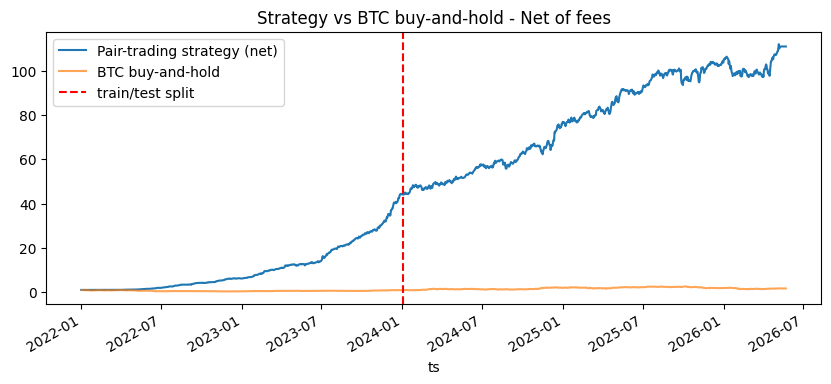

In [18]:
# ____ Net returns (with liquidity aware) + stats ____
daily_costs = compute_liquidity_aware_costs(weights, crypto_px, crypto_vol)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(daily_costs, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")

# ---------- Stats ----------
stats_net = split_stats(port_ret_net, split_date=split_date, ppy=365)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nStats by sample (net of fees):")
print(combined_net)

perf_net = (1 + port_ret_net).cumprod()
btc_perf = (1 + btc_ret).cumprod()
ax = perf_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_perf.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of fees")
ax.legend()
plt.show()